In [4]:
'''
The WordNet Mammal subtree (https://wordnet.princeton.edu)
data from https://papers.nips.cc/paper_files/paper/2017/hash/59dfa2df42d9e3d41f5b02bfc32229dd-Abstract.html 

Get distance matrix for embedding 
After embedding, visualize the embedding
'''
import networkx as nx
import pylab as plt
import numpy as np
import pandas as pd
import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import seaborn as sn
from scipy import stats
import textalloc as ta

import pandas as pd
import networkx as nx

from glob import glob

In [5]:
# plot parameters
plt.style.use('../figures/my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)

In [6]:
def read_edge_file(file_path):
    edges = pd.read_csv(file_path, delim_whitespace=True, header=None, names=['source', 'target'])
    return edges

def create_graph_from_edges(edges):
    G = nx.Graph()
    for _, row in edges.iterrows():
        G.add_edge(row['source'], row['target'])
    return G

In [19]:
# visualize the embedding
def to_native(coords):
    rs = np.linalg.norm(coords,axis=1)
    native_rs = 2.0*np.arctanh(rs)
    coords_new = (coords.T*native_rs).T
    return coords_new

def plot_embedding(pcoords,curvature,nodes,edges,length,rootnode, leavenode, distortion,scalefac = 1.0, coord = 'poin'):
    # perform recenter 
    pcoords_rc = emb.perform_recenter(pcoords,np.arange(len(pcoords)))

    df_toplot = pd.DataFrame({'x':pcoords_rc[:,0],'y':pcoords_rc[:,1]},index=nodes)
    native = to_native(pcoords_rc)
    df_toplot['nativex'] = native[:,0]
    df_toplot['nativey'] = native[:,1]

    # add columns to find distance to root and distance to leave
    len_to_root_dict = length[rootnode]
    df_toplot['len_to_root'] = [len_to_root_dict[node] for node in df_toplot.index]
    len_to_leave_dict = length[leavenode]
    df_toplot['len_to_leave'] = [len_to_leave_dict[node] for node in df_toplot.index]
    df_toplot.head()

    # plot edges
    fig,ax = plt.subplots(figsize=(4,3))

    for i in range(len(edges)):
        name1,name2 = edges.iloc[i]['source'],edges.iloc[i]['target']
        if coord == 'poin':
            ax.plot([df_toplot.loc[name1]['x'],df_toplot.loc[name2]['x']],
                    [df_toplot.loc[name1]['y'],df_toplot.loc[name2]['y']],color='tab:red',
                    linewidth=0.05,zorder = 0)
        elif coord == 'native':
            ax.plot([df_toplot.loc[name1]['nativex'],df_toplot.loc[name2]['nativex']],
                    [df_toplot.loc[name1]['nativey'],df_toplot.loc[name2]['nativey']],color='tab:red',
                    linewidth=0.05,zorder = 0)
    if coord == 'poin':
        df_toplot['xtoplot'] = df_toplot['x']
        df_toplot['ytoplot'] = df_toplot['y']
    elif coord == 'native':
        df_toplot['xtoplot'] = df_toplot['nativex']
        df_toplot['ytoplot'] = df_toplot['nativey']

    sizescalefac = 120//np.max(df_toplot['len_to_root'])

    sc = ax.scatter(
    df_toplot["xtoplot"], df_toplot["ytoplot"],
    # c=df_toplot["len_to_leave"],
    c=df_toplot["len_to_root"],
    # s=(df_toplot["len_to_root"])*sizescalefac*scalefac, # size by distance to mammal
    # cmap="viridis",   
    s=120*scalefac,
    alpha=1.0,
    edgecolors='white',
    linewidths=0.05,
    )

    # for size in [1.0, (1.0+np.max(df_toplot['len_to_root']))/2.0, float(np.max(df_toplot['len_to_root']))]:
    #     ax.scatter([], [], s=size*sizescalefac*scalefac, c='gray', alpha=1.0,
    #                edgecolors='white',linewidths=0.1,
    #             label=str(round(size,2)))
    # # ax.legend(scatterpoints=1, frameon=True, labelspacing=1, title='Length to node %s'%rootnode)
    # ax.legend(scatterpoints=1, frameon=False, labelspacing=1, title='Length to root'%rootnode)
    cbar = plt.colorbar(sc, ax=ax)
    # # cbar.set_label("Length to node %s"%leavenode, fontsize=15)
    # cbar.set_label("Length to leave", fontsize=15)
    cbar.set_label("Length to root", fontsize=15)


    namelist = [leavenode,rootnode]
    # namemap = {leavenode:'Leave',rootnode:'Root'}
    namelist = [rootnode]
    namemap = {rootnode:'Root'}


    ta.allocate_text(fig,ax,df_toplot.loc[namelist]['xtoplot'],
                    df_toplot.loc[namelist]['ytoplot'],
                [namemap[name] for name in namelist],
                max_distance=0.1,
                min_distance=0.01,
                margin=0.0,
                linewidth=1,
                nbr_candidates=200,
                linecolor='blue',
                    textsize=10,
                    avoid_label_lines_overlap=True,
                    seed=3)

    # plot circles at (0,0) of different radius to indicate hyperbolic
    maxradius = np.ceil(np.max(np.sqrt(df_toplot['xtoplot']**2 + df_toplot['ytoplot']**2)))
    rads = np.arange(1,maxradius + 1, 1)
    for r in rads:
        circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', linewidth=0.2)
        ax.add_artist(circle)
    # set x and y limits
    ax.set_xlim(-rads[-1]-0.25, rads[-1]+0.25)
    ax.set_ylim(-rads[-1]-0.25, rads[-1]+0.25)

    # ax.set_xlabel('M-H-MDS-1',fontsize=15)
    # ax.set_ylabel('M-H-MDS-2',fontsize=15)
    # remove axis and box
    ax.set_axis_off()
    # set aspect ratio to equal
    ax.set_aspect('equal', adjustable='box')
    ax.set_title('Average Distortion: %.3f'%distortion,fontsize=15)

    plt.tight_layout()
    


In [8]:
# average distortion
def avedit(dmat1,dmat2):
    offset = abs(dmat2-dmat1)
    N_sample = len(offset)
    dist = offset[np.triu_indices(N_sample, k=1)]/dmat1[np.triu_indices(N_sample, k=1)]
    return np.mean(dist)

In [33]:
datanames = ['bio-diseasome','ca-CSphd','phylo-tree','smalltree']
dataname = datanames[2]

In [34]:
file_path = './edges/%s.edges'%dataname
edges = read_edge_file(file_path)

G = create_graph_from_edges(edges)
G.number_of_nodes()

344

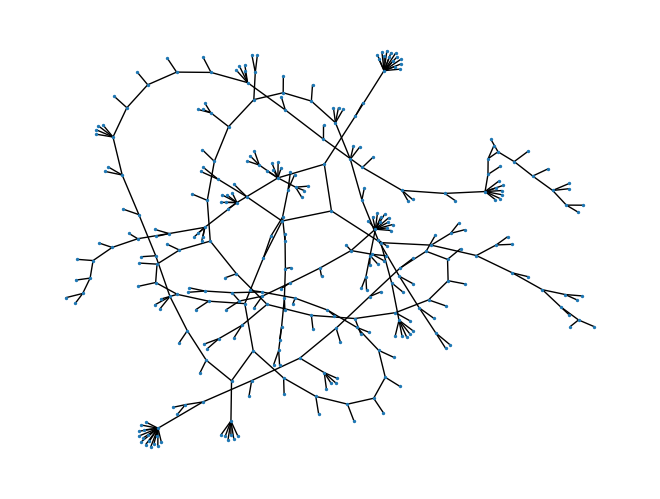

In [35]:
nx.draw(G,pos=nx.spring_layout(G),node_size=2)
# plt.savefig('../../../summary_note/MHMDS_figures/supp/graphs/%s_ori.eps'%dataname,format='eps')

In [36]:
length = dict(nx.all_pairs_dijkstra_path_length(G))
nodes = np.array(G.nodes)
dmat_graph = np.zeros((len(nodes),len(nodes)))
for i in range(len(dmat_graph)):
    for j in range(len(dmat_graph)):
        dmat_graph[i][j] = length[nodes[i]][nodes[j]]

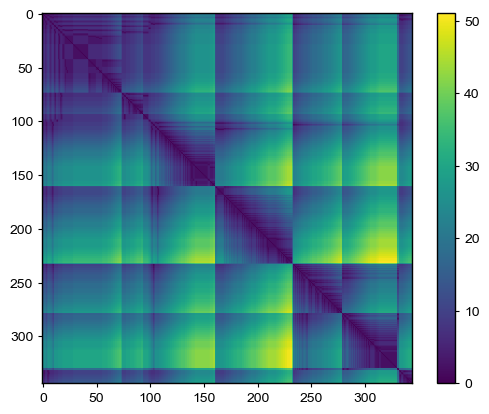

In [37]:
plt.imshow(dmat_graph)
plt.colorbar()

In [38]:
# import os
# if not os.path.exists('../data/DistMat_%s'%dataname):
#     os.makedirs('../data/DistMat_%s'%dataname)
# np.savetxt('../data/DistMat_%s/DistMat_%s.txt'%(dataname,dataname),dmat_graph)

In [39]:
nnodes = G.number_of_nodes()

# from embedding of graph distance directly
pcoords_from_graph = np.loadtxt(glob('../MultiscalehMDS_distance/result/DistMat_%s/cls_*_Nn_*_Nd_2_min_1_max_300_corr_0_coords_%i.txt'
                     %(dataname,nnodes))[0])
inds = np.loadtxt(glob('../MultiscalehMDS_distance/result/DistMat_%s/cls_*_Nn_*_Nd_2_min_1_max_300_corr_0_inds_after_prep.txt'
                 %(dataname))[0])
pcoords_from_graph = pcoords_from_graph[np.argsort(inds)]
curvature_from_graph = pd.read_csv(glob('../MultiscalehMDS_distance/result/DistMat_%s/cls_*_Nn_*_Nd_2_min_1_max_300_corr_0_metrics.csv'
                       %(dataname))[0])['curvature'][0]

In [40]:
# compute average distortion either from embedding of graph distance or embedding of 10d distance
embdmat_from_graph = emb.get_dmat_poin(pcoords_from_graph)/curvature_from_graph
dmat_graph = dmat_graph/np.max(dmat_graph)*2.0


In [41]:
distortion_from_graph = avedit(dmat_graph,embdmat_from_graph)
print('distortion_from_graph:',distortion_from_graph)

distortion_from_graph: 0.10083652919859193


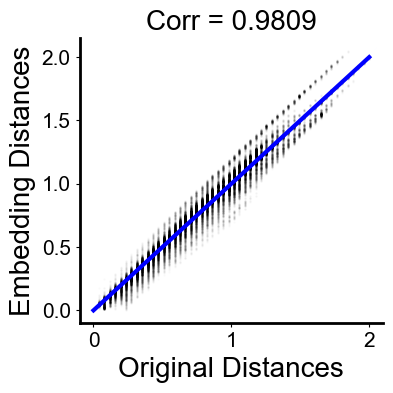

In [42]:
# shepard diagram in both bases
fig,axs = plt.subplots(1,1,figsize=(4,4))
tocompare = [[dmat_graph,embdmat_from_graph]]
axs = [axs]

for i in range(1):
    axs[i].scatter(tocompare[i][0][np.triu_indices(nnodes, k=1)], 
                tocompare[i][1][np.triu_indices(nnodes, k=1)],
                s=1,alpha=0.01,c='k')
    stat,p = stats.pearsonr(tocompare[i][0][np.triu_indices(nnodes,1)],tocompare[i][1][np.triu_indices(nnodes,1)])
    axs[i].set_title('Corr = %.4f'%stat,fontsize=20)
    axs[i].plot(np.arange(0,3),np.arange(0,3),c='b',linewidth=3)
    width=2
    #     ax.spines['top'].set_linewidth(width)
    axs[i].spines['bottom'].set_linewidth(width)
    #     axs[i].spines['bottom'].set_position('zero')
    axs[i].spines['left'].set_linewidth(width)
    #     ax.spines['right'].set_linewidth(width)
    axs[i].spines[['right','top']].set_visible(False)

    axs[i].tick_params(axis="x", labelsize=15)  
    axs[i].tick_params(axis="y", labelsize=15)
    axs[i].set_xlabel('Original Distances', fontsize=20)
    axs[i].set_ylabel('Embedding Distances', fontsize=20)
#     axs[i].set_xticklabels([str(round(float(label), 2)) for label in labels])
plt.tight_layout()



11:08:21 - cmdstanpy - INFO - Chain [1] start processing
11:08:21 - cmdstanpy - INFO - Chain [1] done processing


rootnode: 4
leavenode: 221


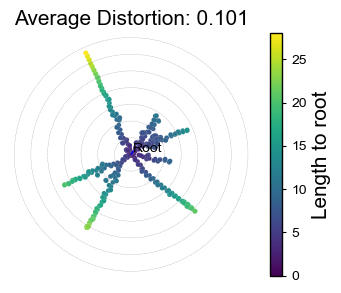

In [43]:
# rootnode: where ave distance is smallest
rootnode = nodes[np.argmin(np.mean(dmat_graph,axis=1))]
# leavenode: where ave distance is largest
leavenode = nodes[np.argmax(np.mean(dmat_graph,axis=1))]
print('rootnode:',rootnode)
print('leavenode:',leavenode)
plot_embedding(pcoords_from_graph,curvature_from_graph,nodes,edges,
               length,rootnode, leavenode,
               distortion_from_graph,scalefac=0.1,coord='native')
# plt.savefig('./%s_new.png'%dataname,dpi=300)
plt.savefig('./%s_new.svg'%dataname,format='svg',transparent=True)

In [55]:
# poincoords = np.load('../WordNet/HoroPCA-main/data/embeddings/%s_10_poincare.npy'%dataname)
# dmat_10d = emb.get_dmat_poin(poincoords)
# plt.imshow(dmat_10d)
# plt.colorbar()

In [ ]:
# pcoords_from_10d = np.loadtxt(glob('../MultiscalehMDS_distance/test/DistMat_%s_2/cls_0.4_Nn_*_Nd_2_min_1_max_300_corr_0_coords_%i.txt'
#                      %(dataname,nnodes))[0])
# inds = np.loadtxt(glob('../MultiscalehMDS_distance/test/DistMat_%s_2/cls_0.4_Nn_*_Nd_2_min_1_max_300_corr_0_inds_after_prep.txt'
#                  %(dataname))[0])
# pcoords_from_10d = pcoords_from_10d[np.argsort(inds)]
# curvature_from_10d= pd.read_csv(glob('../MultiscalehMDS_distance/test/DistMat_%s_2/cls_0.4_Nn_*_Nd_2_min_1_max_300_corr_0_metrics.csv'
#                        %(dataname))[0])['curvature'][0]

In [ ]:
# embdmat_from_10d = emb.get_dmat_poin(pcoords_from_10d)/curvature_from_10d
# dmat_10d = dmat_10d/np.max(dmat_10d)*2.0
# distortion_from_10d = avedit(dmat_10d,embdmat_from_10d)

In [ ]:
# plot_embedding(pcoords_from_10d,curvature_from_10d,nodes,edges,distortion_from_10d,coord='native')